# Breast Cancer Prediction using SVM

## Project Overview

This project uses the Wisconsin Breast Cancer Dataset to predict whether a breast tumor is benign or malignant based on its physical characteristics.

The objective is to build a machine learning model capable of assisting medical decision-making through classification techniques.

Dataset source:
UCI Machine Learning Repository - Wisconsin Diagnostic Breast Cancer Dataset

Tools used:
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn

# 1. Import Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)
# Pandas: data manipulation and analysis
# NumPy: numerical computations
# Matplotlib: data visualization
# Display all columns when printing a DataFrame

# 2. Load Dataset

In [14]:
data = pd.read_csv("wdbc.data", header=None)

data.head()
# Load the Wisconsin Breast Cancer Dataset
# header=None because the file does not contain column names
# head() displays the first five rows

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [15]:
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

Number of rows: 569
Number of columns: 32


# 3. Data Cleaning and Preprocessing

In [16]:
# The original dataset does not contain column names.
# We assign meaningful names to each column based on the dataset documentation.
# This improves readability and makes future analysis easier.
columns = [
    "ID",
    "Diagnosis",
    "Radius_mean",
    "Texture_mean",
    "Perimeter_mean",
    "Area_mean",
    "Smoothness_mean",
    "Compactness_mean",
    "Concavity_mean",
    "Concave_points_mean",
    "Symmetry_mean",
    "Fractal_dimension_mean",

    "Radius_se",
    "Texture_se",
    "Perimeter_se",
    "Area_se",
    "Smoothness_se",
    "Compactness_se",
    "Concavity_se",
    "Concave_points_se",
    "Symmetry_se",
    "Fractal_dimension_se",

    "Radius_worst",
    "Texture_worst",
    "Perimeter_worst",
    "Area_worst",
    "Smoothness_worst",
    "Compactness_worst",
    "Concavity_worst",
    "Concave_points_worst",
    "Symmetry_worst",
    "Fractal_dimension_worst"
]

data.columns = columns

In [18]:
#Removing the patient ID
data = data.drop("ID", axis=1)


The patient ID does not provide any medical information

 It is not useful for prediction and may introduce noise

In [20]:
data["Diagnosis"] = data["Diagnosis"].map({
    "M": 1,
    "B": 0
})
data.head()

,Diagnosis,Radius_mean,Texture_mean,Perimeter_mean,Area_mean,Smoothness_mean,Compactness_mean,Concavity_mean,Concave_points_mean,Symmetry_mean,Fractal_dimension_mean,Radius_se,Texture_se,Perimeter_se,Area_se,Smoothness_se,Compactness_se,Concavity_se,Concave_points_se,Symmetry_se,Fractal_dimension_se,Radius_worst,Texture_worst,Perimeter_worst,Area_worst,Smoothness_worst,Compactness_worst,Concavity_worst,Concave_points_worst,Symmetry_worst,Fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


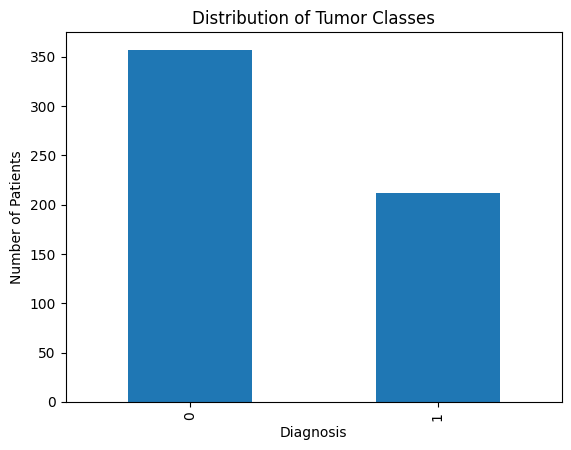

In [21]:
# Visual representation of the target variable distribution.
data["Diagnosis"].value_counts().plot(kind="bar")

plt.title("Distribution of Tumor Classes")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")

plt.show()

In [22]:
# Check whether any feature contains missing values.
data.isnull().sum()

Diagnosis                  0
Radius_mean                0
Texture_mean               0
Perimeter_mean             0
Area_mean                  0
Smoothness_mean            0
Compactness_mean           0
Concavity_mean             0
Concave_points_mean        0
Symmetry_mean              0
Fractal_dimension_mean     0
Radius_se                  0
Texture_se                 0
Perimeter_se               0
Area_se                    0
Smoothness_se              0
Compactness_se             0
Concavity_se               0
Concave_points_se          0
Symmetry_se                0
Fractal_dimension_se       0
Radius_worst               0
Texture_worst              0
Perimeter_worst            0
Area_worst                 0
Smoothness_worst           0
Compactness_worst          0
Concavity_worst            0
Concave_points_worst       0
Symmetry_worst             0
Fractal_dimension_worst    0
dtype: int64

# 4. Exploratory Data Analysis (EDA)

In [23]:
# Summary statistics for all numerical variables.
# Includes:
# count
# mean
# standard deviation
# minimum
# quartiles
# maximum
data.describe()

,Diagnosis,Radius_mean,Texture_mean,Perimeter_mean,Area_mean,Smoothness_mean,Compactness_mean,Concavity_mean,Concave_points_mean,Symmetry_mean,Fractal_dimension_mean,Radius_se,Texture_se,Perimeter_se,Area_se,Smoothness_se,Compactness_se,Concavity_se,Concave_points_se,Symmetry_se,Fractal_dimension_se,Radius_worst,Texture_worst,Perimeter_worst,Area_worst,Smoothness_worst,Compactness_worst,Concavity_worst,Concave_points_worst,Symmetry_worst,Fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


The features are measured on very different scales.
For example, Area_mean has values around 650 while Smoothness_mean has values around 0.1. Since SVM is distance-based, feature scaling will be necessary before training the model.

# Correlation Analysis

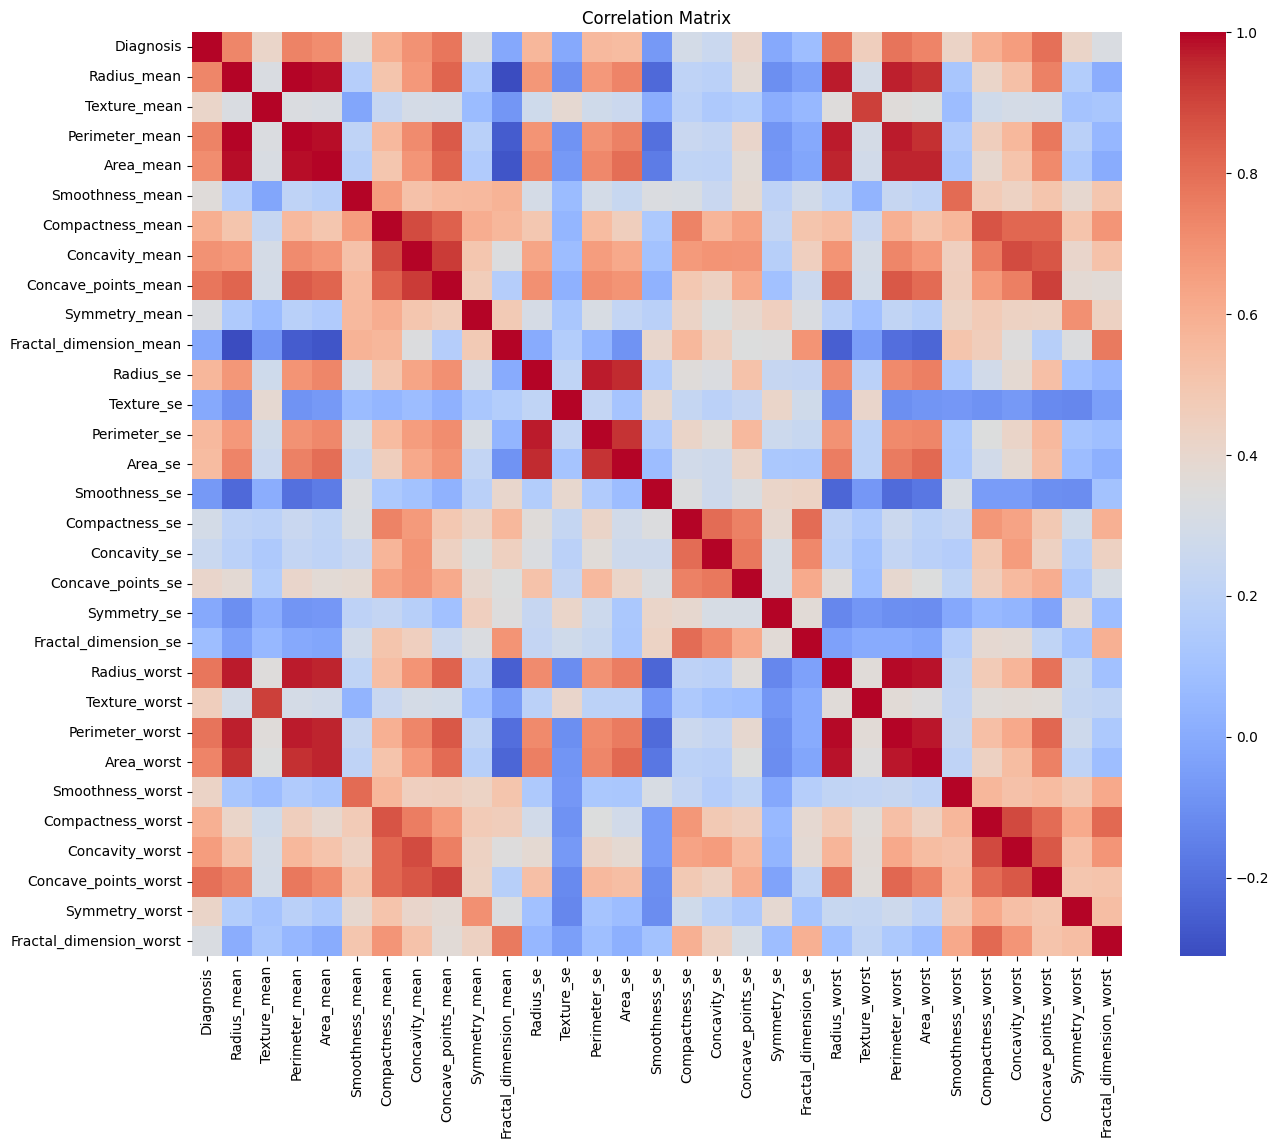

In [25]:
plt.figure(figsize=(15,12))

sns.heatmap(
    data.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

 The correlation matrix helps identify relationships between variables and detect highly correlated features.
 
 Values range from -1 to +1.

# Correlation with the Target Variable


In [28]:
# Compute the correlation between each feature and the target variable.
corr_target = data.corr()["Diagnosis"].sort_values(ascending=False)

print(corr_target)

Diagnosis                  1.000000
Concave_points_worst       0.793566
Perimeter_worst            0.782914
Concave_points_mean        0.776614
Radius_worst               0.776454
Perimeter_mean             0.742636
Area_worst                 0.733825
Radius_mean                0.730029
Area_mean                  0.708984
Concavity_mean             0.696360
Concavity_worst            0.659610
Compactness_mean           0.596534
Compactness_worst          0.590998
Radius_se                  0.567134
Perimeter_se               0.556141
Area_se                    0.548236
Texture_worst              0.456903
Smoothness_worst           0.421465
Symmetry_worst             0.416294
Texture_mean               0.415185
Concave_points_se          0.408042
Smoothness_mean            0.358560
Symmetry_mean              0.330499
Fractal_dimension_worst    0.323872
Compactness_se             0.292999
Concavity_se               0.253730
Fractal_dimension_se       0.077972
Symmetry_se               -0

 Positive values indicate that the feature tends to increase  when the tumor is malignant.

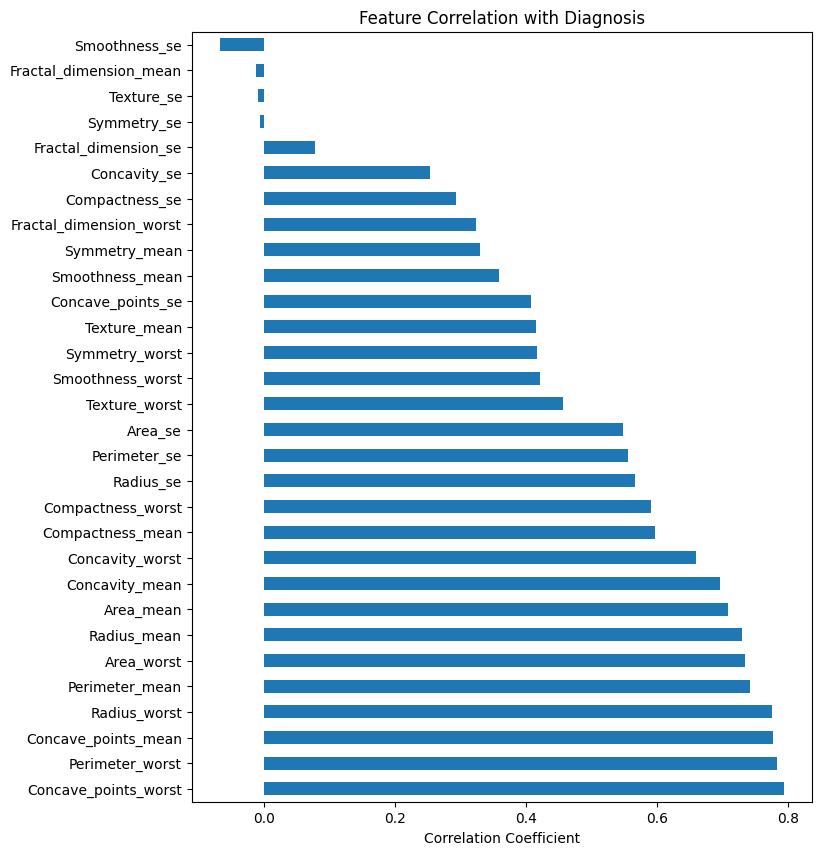

In [29]:
plt.figure(figsize=(8,10))

corr_target.drop("Diagnosis").plot(kind="barh")

plt.title("Feature Correlation with Diagnosis")
plt.xlabel("Correlation Coefficient")

plt.show()

# 5. Data Preparation and Train-Test Split

In [30]:
# X contains the input features.
# y contains the target variable (diagnosis).
X = data.drop("Diagnosis", axis=1)

y = data["Diagnosis"]


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


80% of the data is used for training.

20% is reserved for testing.

random_state ensures reproducibility.

In [32]:
print(X_train.shape)
print(X_test.shape)


(455, 30)
(114, 30)


# 6. Feature Scaling

Support Vector Machines are sensitive to feature magnitudes.

To ensure that all features contribute equally to the model, the data is standardized using StandardScaler.

After scaling:
- Mean = 0
- Standard Deviation = 1

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)
# Standardize all features.
# Mean = 0
# Standard deviation = 1
#
# SVM is distance-based and requires feature scaling.

# 7. Dimensionality Reduction with PCA
The dataset contains 30 features for each patient. To better understand the data structure and visualize if there is a natural separation between benign and malignant tumors, we will apply Principal Component Analysis (PCA). The goal is to reduce these 30 dimensions to just 2 or 3 principal components while retaining as much information (variance) as possible.


In [54]:
from sklearn.decomposition import PCA

# Instantiate PCA without limiting the number of components initially
pca = PCA()

# Apply PCA on the scaled training data
X_train_pca = pca.fit_transform(X_train_scaled)

# Calculate the percentage of variance explained by each component
explained_variance = pca.explained_variance_ratio_

print(f"Variance explained by the 1st component: {explained_variance[0]:.2f}")
print(f"Variance explained by the 2nd component: {explained_variance[1]:.2f}")


Variance explained by the 1st component: 0.44
Variance explained by the 2nd component: 0.20


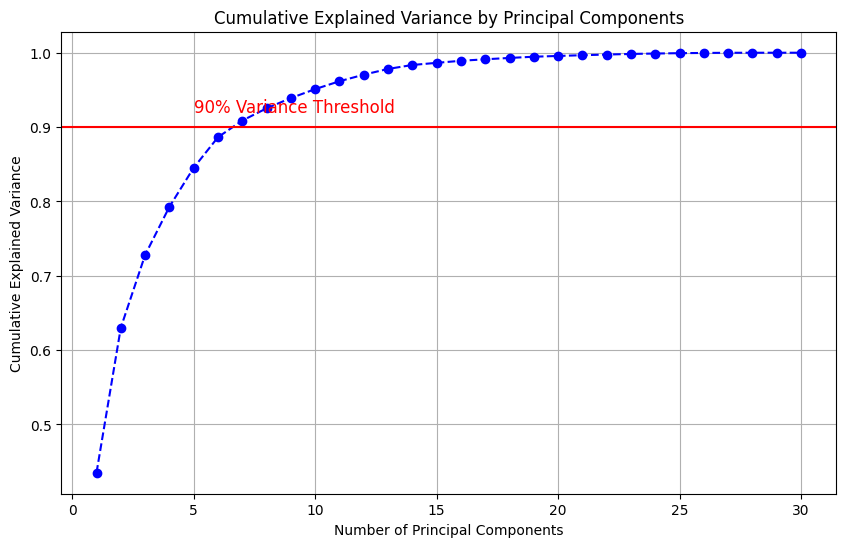

In [55]:
# Calculate the cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')

# Plot styling
plt.title('Cumulative Explained Variance by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)

# Add a horizontal line at 90% variance for reference
plt.axhline(y=0.90, color='r', linestyle='-')
plt.text(5, 0.92, '90% Variance Threshold', color='red', fontsize=12)

plt.show()

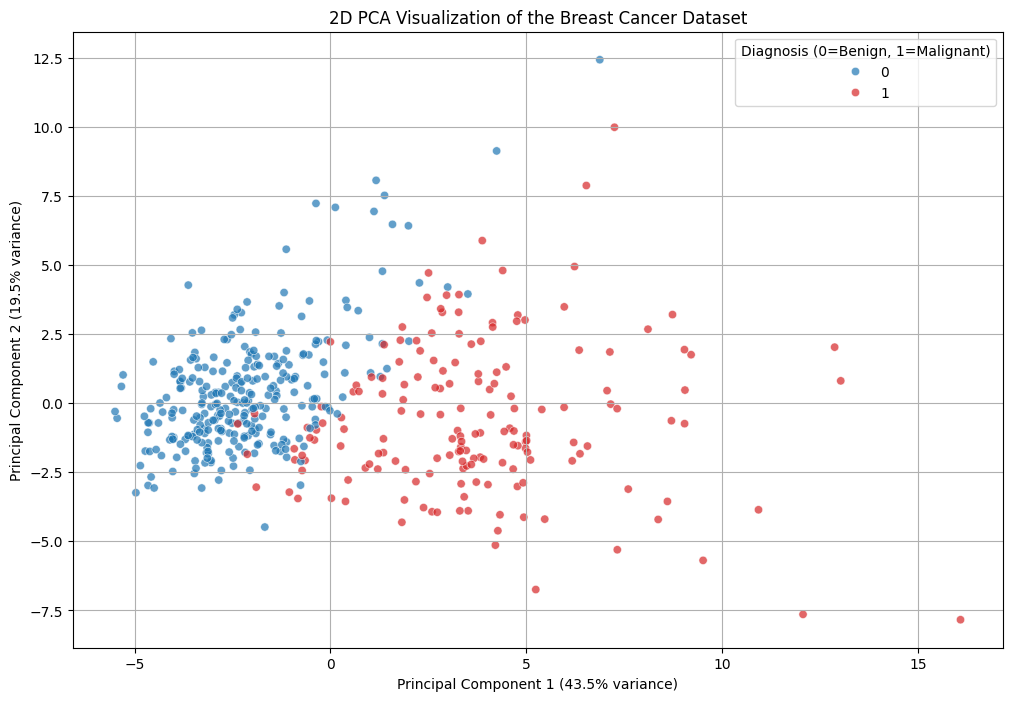

In [56]:
# Re-apply PCA keeping only the top 2 components for 2D visualization
pca_2d = PCA(n_components=2)
X_train_pca_2d = pca_2d.fit_transform(X_train_scaled)

# Create a DataFrame for easier plotting with Seaborn
pca_df = pd.DataFrame(data=X_train_pca_2d, columns=['Principal Component 1', 'Principal Component 2'])

# Add the target variable (Diagnosis) back to the dataframe
pca_df['Diagnosis'] = y_train.values

# Plotting the 2D PCA
plt.figure(figsize=(12, 8))

# Scatter plot colored by diagnosis (0 = Benign, 1 = Malignant)
sns.scatterplot(
    x='Principal Component 1', 
    y='Principal Component 2', 
    hue='Diagnosis', 
    palette=['#1f77b4', '#d62728'], # Blue and Red
    data=pca_df,
    alpha=0.7
)

# Plot styling and labels
plt.title('2D PCA Visualization of the Breast Cancer Dataset')
plt.xlabel(f"Principal Component 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"Principal Component 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(title='Diagnosis (0=Benign, 1=Malignant)')
plt.grid(True)

plt.show()

### PCA Interpretation

The first two principal components capture a substantial proportion of the total variance in the dataset. The visualization reveals a clear separation between benign and malignant tumors, explaining the strong classification performance achieved by the SVM model.

# 8. Model Training (SVM)

In [35]:
from sklearn.svm import SVC

svm_model = SVC()

svm_model.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [37]:
y_pred = svm_model.predict(X_test_scaled)
# Predict the diagnosis for unseen patients.

# 9. Model Evaluation

In [39]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
# Accuracy = Number of correct predictions / Total predictions

Accuracy: 0.9824561403508771


In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)


[[71  0]
 [ 2 41]]


In [42]:
### Interpretation

#The confusion matrix shows that the SVM classifier achieved excellent performance on the test dataset. The model correctly classified 71 benign tumors and 41 malignant tumors. No benign tumors were incorrectly classified as malignant, resulting in zero false positives. Only 2 malignant tumors were misclassified as benign, representing the false negatives.

#From a clinical perspective, false negatives are the most critical type of error because they correspond to cancer cases that remain undetected. The model produced only two false negatives, indicating a strong ability to identify malignant tumors. Overall, the confusion matrix demonstrates that the SVM model is highly effective and reliable for breast cancer classification.

## Visualizing the Confusion Matrix


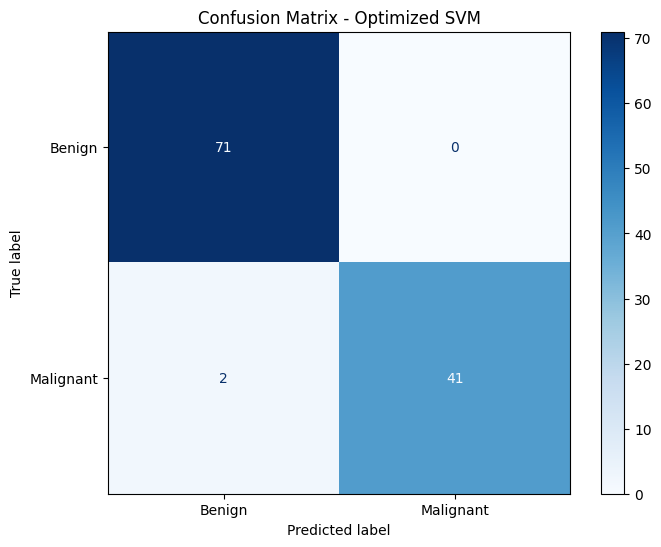

In [57]:
from sklearn.metrics import ConfusionMatrixDisplay

# Affiche la matrice proprement
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_svm, X_test_scaled, y_test, 
                                      display_labels=["Benign", "Malignant"], 
                                      cmap="Blues", ax=ax)
plt.title("Confusion Matrix - Optimized SVM")
plt.show()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


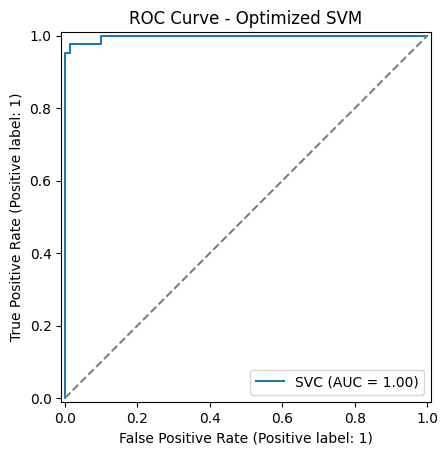

In [58]:
from sklearn.metrics import RocCurveDisplay

# Courbe ROC pour évaluer la performance de classification
RocCurveDisplay.from_estimator(best_svm, X_test_scaled, y_test)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray') # Ligne de chance aléatoire
plt.title("ROC Curve - Optimized SVM")
plt.show()

# 10. Classification Report

## code

In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.97      1.00      0.99        71
           1       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## Important Metrics

Precision

      Among predicted malignant tumors,
      how many are truly malignant?
Recall (Sensitivity)

      Among actual malignant tumors,
      how many did we detect?
F1-score

      Balance between Precision and Recall

# 11. Comparison of SVM Kernels

## Train a Linear SVM

In [46]:

linear_svm = SVC(kernel="linear")

linear_svm.fit(X_train_scaled, y_train)

linear_pred = linear_svm.predict(X_test_scaled)

linear_accuracy = accuracy_score(y_test, linear_pred)

print("Linear SVM Accuracy:", linear_accuracy)

Linear SVM Accuracy: 0.956140350877193


## Comparison Table

In [48]:
comparison = pd.DataFrame({
    "Kernel": ["Linear", "RBF"],
    "Accuracy": [linear_accuracy, accuracy]
})

comparison

,Kernel,Accuracy
0,Linear,0.956140
1,RBF,0.982456


# 12. Hyperparameter Tuning with GridSearchCV


In [49]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1],
    "kernel": ["rbf"]
}

grid_search = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': [0.001, 0.01, ...], 'kernel': ['rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold

In [50]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

Best Parameters: {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.9736263736263737


## Train the Optimized Model

In [51]:
best_svm = grid_search.best_estimator_

best_pred = best_svm.predict(X_test_scaled)

from sklearn.metrics import accuracy_score

optimized_accuracy = accuracy_score(y_test, best_pred)

print("Optimized Accuracy:", optimized_accuracy)

Optimized Accuracy: 0.9824561403508771


### Interpretation



GridSearchCV identified the optimal hyperparameters for the RBF Support Vector Machine as C = 100 and gamma = 0.001. The model achieved a cross-validation accuracy of 97.36%, indicating strong generalization performance across different training subsets.

After training the optimized model on the full training set, the test accuracy reached 98.25%. Interestingly, the optimized model achieved the same test accuracy as the default RBF SVM. This suggests that the default parameters were already well suited to this dataset. Nevertheless, hyperparameter tuning remains an important step because it confirms that the selected model configuration is close to optimal and provides additional confidence in the model's robustness.



In [59]:
results = pd.DataFrame({
    "Model": [
        "Linear SVM",
        "RBF SVM",
        "Optimized RBF SVM"
    ],
    "Accuracy": [
        linear_accuracy,
        accuracy,
        optimized_accuracy
    ]
})

results

,Model,Accuracy
0,Linear SVM,0.956140
1,RBF SVM,0.982456
2,Optimized RBF SVM,0.982456


# Conclusion

This project demonstrated the effectiveness of Support Vector Machines (SVM) for breast cancer diagnosis using the Wisconsin Diagnostic Breast Cancer Dataset.

The RBF kernel achieved the best performance, reaching an accuracy of 98.25%. Hyperparameter tuning with GridSearchCV confirmed that the model was already operating near its optimal configuration.

The low number of false negatives highlights the model's ability to identify malignant tumors, making it particularly relevant for medical classification tasks.

Future improvements may include deployment through a web application, additional validation techniques, and comparisons with other machine learning algorithms such as Random Forests and XGBoost.